In [10]:
import pandas as pd

btc = pd.read_csv("/Users/lizeyu/Desktop/Quant-on-Crypto/strategies/union-strategies/5m_klines_raw/BTCUSDT_klines_5m.csv")
# doge = pd.read_csv("5m_klines_raw/DOGEUSDT_klines_5m.csv")
# pepe = pd.read_csv("5m_klines_raw/PEPEUSDT_klines_5m.csv")
for df in [btc]:
    df['Close Time'] = df['Close Time'].apply(lambda x: x * 1000+999 if x < 2000000000000 else x)
    df['Open Time'] = df['Open Time'].apply(lambda x: x * 1000 if x < 2000000000000 else x)
    df['Open Time'] = pd.to_datetime(df['Open Time'], unit='us')
    df['Close Time'] = pd.to_datetime(df['Close Time'], unit='us')



period = ['2024-01-01', '2025-01-01']
btc = btc.set_index('Open Time').loc[period[0]:period[1]]
# doge = doge.set_index('Open Time').loc[period[0]:period[1]]
# pepe = pepe.set_index('Open Time').loc[period[0]:period[1]]

In [11]:
df = btc

In [12]:
btc

,Close Time,index,Open,High,Low,Close,Volume,Quote Asset Volume,Number of Trades,Taker Buy Base Volume,Taker Buy Quote Volume,Ignore
Open Time,,,,,,,,,,,,
2024-01-01 00:00:00,2024-01-01 00:04:59.999999,0,42283.58,42397.23,42261.02,42397.23,155.25731,6.572926e+06,6350,106.05732,4.490262e+06,0
2024-01-01 00:05:00,2024-01-01 00:09:59.999999,1,42397.22,42432.74,42385.26,42409.96,141.31102,5.993375e+06,5134,69.45156,2.945452e+06,0
2024-01-01 00:10:00,2024-01-01 00:14:59.999999,2,42409.97,42488.09,42409.96,42488.00,135.14249,5.738386e+06,5167,73.25966,3.110338e+06,0
2024-01-01 00:15:00,2024-01-01 00:19:59.999999,3,42488.00,42554.57,42458.58,42458.85,163.32541,6.943230e+06,6153,82.81591,3.520689e+06,0
2024-01-01 00:20:00,2024-01-01 00:24:59.999999,4,42458.85,42491.10,42445.84,42473.93,117.27112,4.979136e+06,3094,49.06278,2.083183e+06,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01 23:35:00,2025-01-01 23:39:59.999999,105691,94691.11,94691.11,94542.00,94623.99,39.95100,3.779940e+06,6950,20.14709,1.906048e+06,0
2025-01-01 23:40:00,2025-01-01 23:44:59.999999,105692,94623.99,94757.29,94623.99,94732.01,18.70048,1.770929e+06,3758,10.04054,9.508234e+05,0
2025-01-01 23:45:00,2025-01-01 23:49:59.999999,105693,94732.01,94756.61,94642.93,94642.94,27.21850,2.578091e+06,4590,8.89524,8.427145e+05,0


In [13]:
# 添加一列表示 index 所在的小时
df['Hour'] = df.index.hour
df['Day'] = df.index.date

# 添加一列表示 Close 相对于 144 行前的涨幅
df['Close_Change_12'] = (df['Close'].shift(-12)-df['Close']) / df['Close']
df['Close_Change_144'] = (df['Close'].shift(-144)-df['Close']) / df['Close']

df.head(20)

,Close Time,index,Open,High,Low,Close,Volume,Quote Asset Volume,Number of Trades,Taker Buy Base Volume,Taker Buy Quote Volume,Ignore,Hour,Day,Close_Change_12,Close_Change_144
Open Time,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,2024-01-01 00:04:59.999999,0,42283.58,42397.23,42261.02,42397.23,155.25731,6.572926e+06,6350,106.05732,4.490262e+06,0,0,2024-01-01,0.000903,0.006987
2024-01-01 00:05:00,2024-01-01 00:09:59.999999,1,42397.22,42432.74,42385.26,42409.96,141.31102,5.993375e+06,5134,69.45156,2.945452e+06,0,0,2024-01-01,0.000633,0.005658
2024-01-01 00:10:00,2024-01-01 00:14:59.999999,2,42409.97,42488.09,42409.96,42488.00,135.14249,5.738386e+06,5167,73.25966,3.110338e+06,0,0,2024-01-01,-0.000510,0.003260
2024-01-01 00:15:00,2024-01-01 00:19:59.999999,3,42488.00,42554.57,42458.58,42458.85,163.32541,6.943230e+06,6153,82.81591,3.520689e+06,0,0,2024-01-01,0.000819,0.004870
2024-01-01 00:20:00,2024-01-01 00:24:59.999999,4,42458.85,42491.10,42445.84,42473.93,117.27112,4.979136e+06,3094,49.06278,2.083183e+06,0,0,2024-01-01,0.000097,0.004949
2024-01-01 00:25:00,2024-01-01 00:29:59.999999,5,42473.93,42500.00,42412.02,42419.73,111.65236,4.739498e+06,4085,43.64197,1.852694e+06,0,0,2024-01-01,0.001731,0.006233
2024-01-01 00:30:00,2024-01-01 00:34:59.999999,6,42419.73,42419.73,42354.19,42362.93,77.85936,3.299938e+06,4552,29.46018,1.248498e+06,0,0,2024-01-01,0.004775,0.007818
2024-01-01 00:35:00,2024-01-01 00:39:59.999999,7,42362.93,42447.82,42355.36,42447.82,149.18862,6.324233e+06,3542,114.68252,4.861573e+06,0,0,2024-01-01,0.006354,0.007773
2024-01-01 00:40:00,2024-01-01 00:44:59.999999,8,42447.82,42447.82,42396.50,42441.32,92.85846,3.939920e+06,2865,47.85757,2.030573e+06,0,0,2024-01-01,0.006036,0.007409


Processing: 100%|██████████| 105696/105696 [00:00<00:00, 195879.85it/s]


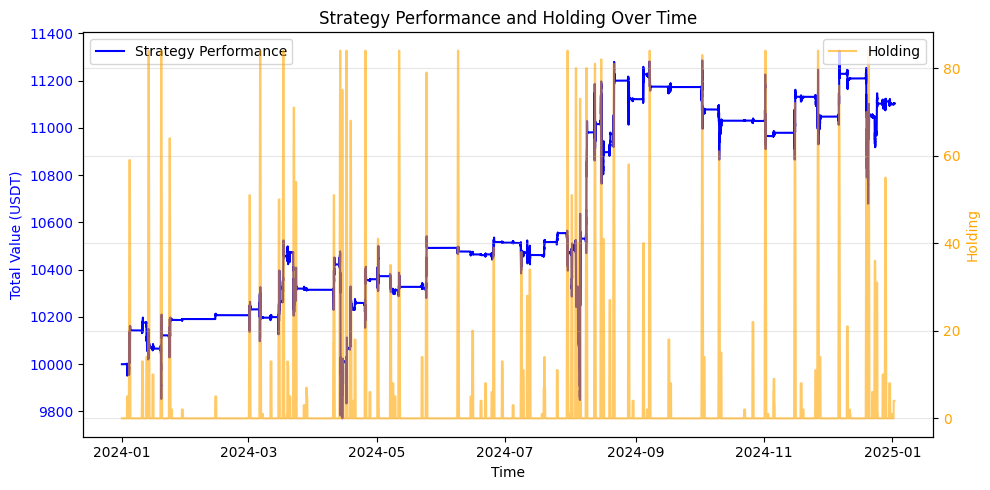

In [14]:
import numpy as np
import pandas as pd
from collections import deque
from tqdm import tqdm

def implement_strategy(
    btc: pd.DataFrame,
    trade_size: float=1000.0,
    initial_cap: float = 10000.0,
    fee: float = 0.0005,
    threshold: float = -0.02,
    max_holding: int = 24,

):

    prices = btc["Close"].values
    n = len(prices)

    # 预分配结果
    total_value = np.zeros(n)
    holdings_array = np.zeros(n)
    pnl_records = np.zeros(n)  # 每次平仓的收益率记录

    # 策略状态
    capital = initial_cap     # USDT
    amount = 0.0              # 持仓BTC数量
    open_orders = deque()     # 存储未平仓订单 [{time, price, qty}]
    now_holding = 0

    for t in tqdm(range(n), desc="Processing"):
        price_t = prices[t]
        total_value[t] = capital + amount * price_t
        holdings_array[t] = now_holding

        # --- 买入信号 ---
        if (
            t >= 288 
            and btc['Close_Change_144'].iloc[t-288]<threshold
            and now_holding<max_holding
            and btc['Hour'].iloc[t] in [7,8,9,10,11,12,13]  # 只能在0点、8点、16点买
        ):
            qty = trade_size / price_t
            cost = trade_size * (1 + fee)

            if capital >= cost:  # 资金充足才买
                capital -= cost
                amount += qty
                now_holding += 1
                open_orders.append({"time": t, "price": price_t, "qty": qty})
             
        if now_holding > 0:
            # 平多仓
            while open_orders and open_orders[0]["time"] <= t - 144:
                order = open_orders.popleft()
                sell_qty = order["qty"]
                sell_price = price_t
                proceeds = sell_qty * sell_price * (1 - fee)
                capital += proceeds
                amount -= sell_qty
                now_holding -= 1

                # 计算并记录收益率
                entry_price = order["price"]
                pnl = (sell_price - entry_price) / entry_price
                pnl_records[t] += pnl
       
    # 生成结果
    performance_df = pd.DataFrame(
        {"Total Value": total_value}, index=btc.index
    )
    holding_series = pd.Series(holdings_array, index=btc.index)
    pnl_series = pd.Series(pnl_records, index=btc.index)
    return performance_df, pnl_series, holding_series


# 运行优化后的策略
strategy_performance, pnls, holding = implement_strategy(
    btc,
    trade_size=100.0,
    initial_cap=10000.0,
    fee=0.0005,
    threshold=-0.02,
    max_holding=100,

)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ax1 = plt.gca()
ax2 = ax1.twinx()





# 策略表现
ax1.plot(strategy_performance.index, strategy_performance['Total Value'], label='Strategy Performance', color='blue')
ax1.set_ylabel('Total Value (USDT)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# 持仓
ax2.plot(strategy_performance.index, holding.values, label='Holding', color='orange', alpha=0.6)
ax2.set_ylabel('Holding', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Strategy Performance and Holding Over Time')
ax1.set_xlabel('Time')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# 筛选出 pnls 不等于 0 的值
non_zero_pnls = pnls[pnls != 0]

# 打印前几行以验证
print(non_zero_pnls.head())
# 将 pnls 转换为 numpy 数组以便计算
import numpy as np
pnls_array = np.array(non_zero_pnls)

# 计算基本统计指标
stats = {
    "总交易次数": len(pnls_array),
    "平均收益率": np.mean(pnls_array),
    "中位数收益率": np.median(pnls_array),
    "最大收益率": np.max(pnls_array),
    "最小收益率": np.min(pnls_array),
    "标准差": np.std(pnls_array),
    "正收益交易数": np.sum(pnls_array > 0),
    "负收益交易数": np.sum(pnls_array < 0),
    "胜率": np.mean(pnls_array > 0),
    "盈亏比": np.mean(pnls_array[pnls_array > 0]) / abs(np.mean(pnls_array[pnls_array < 0])) if np.any(pnls_array < 0) else float('inf'),
    "夏普比率": np.mean(pnls_array) / np.std(pnls_array) if np.std(pnls_array) > 0 else 0,
    "总收益率": np.sum(pnls_array)
}

# 打印统计指标
for key, value in stats.items():
    print(f"{key}: {value:.4f}" if isinstance(value, (float, np.float64)) else f"{key}: {value}")

Open Time
2024-01-03 20:50:00   -0.053423
2024-01-03 20:55:00   -0.054845
2024-01-03 21:00:00   -0.054769
2024-01-03 21:05:00   -0.058387
2024-01-03 21:25:00   -0.055968
dtype: float64
总交易次数: 3654
平均收益率: 0.0040
中位数收益率: 0.0030
最大收益率: 0.1252
最小收益率: -0.1154
标准差: 0.0257
正收益交易数: 2066
负收益交易数: 1588
胜率: 0.5654
盈亏比: 1.1843
夏普比率: 0.1561
总收益率: 14.6678


In [16]:
sp = pd.read_csv("/Users/lizeyu/Desktop/Quant-on-Crypto/strategies/trend_strategy/total_sum.csv", index_col=0, parse_dates=True)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/lizeyu/Desktop/Quant-on-Crypto/strategies/trend_strategy/total_sum.csv'

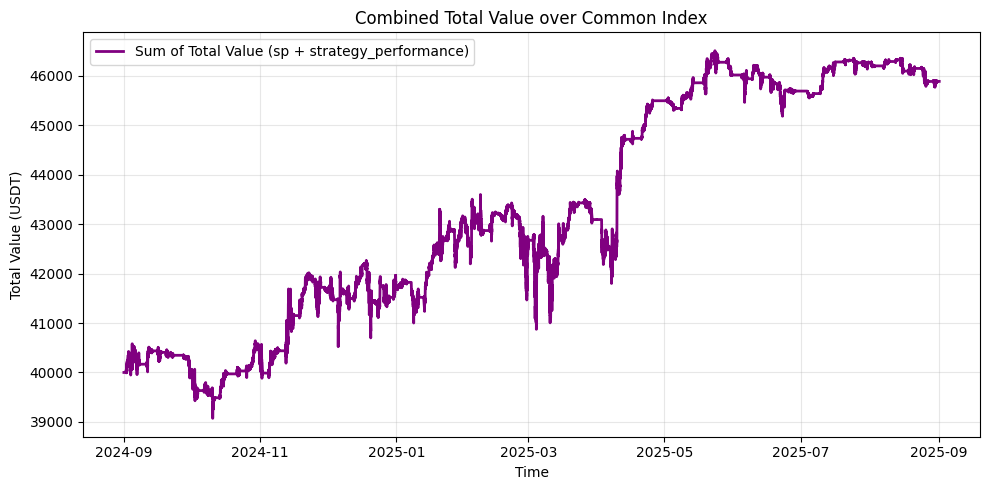

In [ ]:
import matplotlib.pyplot as plt

# 1️⃣ 取时间索引交集并排序
common_index = sp.index.intersection(strategy_performance.index).sort_values()

# 2️⃣ 对齐后求和
total_sum = sp.loc[common_index, "Total Value"] + \
            strategy_performance.loc[common_index, "Total Value"]

# 3️⃣ 画图
plt.figure(figsize=(10,5))
plt.plot(common_index, total_sum, color="purple", lw=2,
         label="Sum of Total Value (sp + strategy_performance)")
plt.title("Combined Total Value over Common Index")
plt.xlabel("Time")
plt.ylabel("Total Value (USDT)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
